# Assignment 1A: Water scarcity in the Netherlands
*Note:* This notebook is only a slight adjustment from the Week 2 SIP practical. Do not forget to have *csp26* as your kernel! :)

Given only the signs of the links, which intervention variable has the strongest effect on freshwater availability, and how sure can we be?


## 0. Setup

In [1]:
SIP_PIN = "v0.4.0"
try:
    import sip_systemsinsightpipeline as sip
except ImportError:
    %pip install -q "git+https://github.com/vvvasconcelos/SystemsInsightPipeline.git@v0.4.0"
    import sip_systemsinsightpipeline as sip

import numpy as np, pandas as pd, networkx as nx, matplotlib.pyplot as plt
from sip_systemsinsightpipeline import Extract, SDM

XLSX = "waterscarcity_cld.xlsx"
print("SIP", sip.__version__, "ready")

SIP 0.5.0 ready


### Presentation only

Colours and plot helpers.

In [2]:
# --- decorative ---------------------------------------------------------
TEAL, DARK_TEAL, CORAL, SLATE, MINT, AMBER = (
    "#00A39B", "#006661", "#E8633A", "#5F6B7A", "#9FE1CB", "#E6A700")
KIND_COLOR = {"Stock": TEAL, "Auxiliary": MINT, "Constant": AMBER}


def draw_cld(G, ax=None):
    """Node fill = variable kind, edge colour = link sign."""
    ax = ax or plt.subplots(figsize=(8.5, 6))[1]
    pos = nx.spring_layout(G, pos=nx.kamada_kawai_layout(G), k=0.5, iterations=60, seed=7)
    nx.draw_networkx_nodes(
        G, pos, node_size=3000, edgecolors=DARK_TEAL, ax=ax,
        node_color=[KIND_COLOR[G.nodes[n]["kind"]] for n in G])
    nx.draw_networkx_edges(
        G, pos, node_size=3000, width=2, arrowstyle="-|>", arrowsize=18,
        connectionstyle="arc3,rad=0.16", ax=ax,
        edge_color=[TEAL if d["sign"] == "+" else CORAL for *_, d in G.edges(data=True)])
    nx.draw_networkx_labels(G, pos, {n: n.replace(" ", "\n") for n in G}, font_size=8, ax=ax)
    ax.set_title("teal + / coral -   |   stock=teal, auxiliary=mint, constant=amber",
                 color=DARK_TEAL, fontsize=10)
    ax.axis("off")
    ax.legend(handles=[plt.Line2D([], [], marker="o", ls="", markersize=10, label=k,
                                  markerfacecolor=c, markeredgecolor=DARK_TEAL)
                       for k, c in KIND_COLOR.items()], loc="lower left", frameon=False)
    plt.tight_layout()


def plot_spread(lev, voi, title):
    """One box per lever: the distribution of its effect on the outcome."""
    fig, ax = plt.subplots(figsize=(8.5, 4.2))
    bp = ax.boxplot(list(lev.values()), vert=False, tick_labels=list(lev),
                    patch_artist=True, medianprops=dict(color=DARK_TEAL, lw=2))
    for box in bp["boxes"]:
        box.set(facecolor=MINT, alpha=.75)
    ax.axvline(0, color=SLATE, ls=":", lw=1)
    ax.set_xlabel(f"Effect on '{voi}'")
    ax.set_title(title, color=DARK_TEAL)
    plt.tight_layout()


def plot_ranking(r, voi):
    """Median effect per lever, 5-95% interval as the error bar."""
    r = r.sort_values("median")
    fig, ax = plt.subplots(figsize=(8.5, 3.8))
    ax.barh(r.index, r["median"], color=TEAL, height=.62,
            xerr=[r["median"] - r["lo"], r["hi"] - r["median"]],
            error_kw=dict(ecolor=SLATE, lw=1.4, capsize=4))
    ax.axvline(0, color=SLATE, ls=":", lw=1)
    ax.set_xlabel(f"Median effect on '{voi}'  (bar = 5-95%)")
    ax.set_title("Which lever matters most?", color=DARK_TEAL)
    plt.tight_layout()

## 1. The diagram

The CLD combines freshwater stocks, water-use variables, and external drivers.
The `Elements` sheet gives each variable a kind; `Connections` gives the signed links.


,Label,Type,Tags,Description
0,Open water,Stock,0,NaN
1,Temperature,Auxiliary,0,NaN
2,River inflow,Constant,1,NaN
3,Rain fall,Constant,1,NaN
4,Agricultural water use,Auxiliary,0,NaN
5,Evaporation,Auxiliary,0,NaN
6,Ground water,Stock,0,NaN
7,Industrial water use,Auxiliary,0,NaN
8,River outflow,Constant,1,NaN
9,Fresh water usage,Auxiliary,0,NaN


,From,To,Type
0,Fresh water availibity,Evaporation,+
1,Evaporation,Open water,-
2,Evaporation,Rain fall,+
3,Open water,Fresh water availibity,+
4,Rain fall,Open water,+
5,Rain fall,River inflow,+
6,Rain fall,Ground water,+
7,River inflow,Open water,+
8,River inflow,Ground water,+
9,Ground water,Fresh water availibity,+


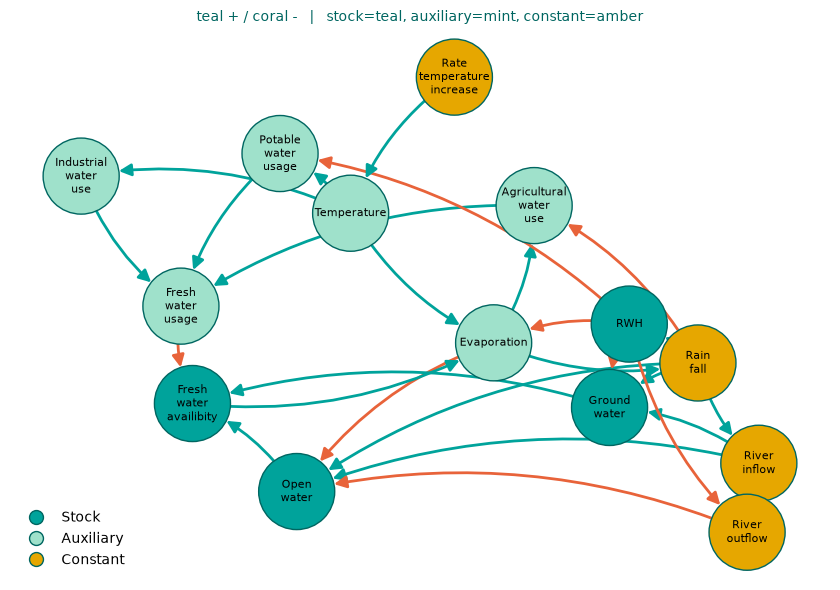

In [3]:
elem = pd.read_excel(XLSX, sheet_name="Elements")
conn = pd.read_excel(XLSX, sheet_name="Connections")

G = nx.DiGraph()
G.add_nodes_from((r.Label, {"kind": r.Type}) for r in elem.itertuples())
G.add_edges_from((r.From, r.To, {"sign": r.Type}) for r in conn.itertuples())

display(elem, conn[["From", "To", "Type"]])
draw_cld(G)

## 2. What SIP reads

`extract_settings()` classifies the variables and identifies the feedback structure that can be represented in the D2D model.


In [4]:
s = Extract(XLSX).extract_settings()
voi = s.variable_of_interest[0]

for field in ["variable_of_interest", "intervention_variables", "stocks", "auxiliaries", "constants"]:
    print(f"{field:22s}", getattr(s, field))

Variable of interest: Fresh water availibity
with 4 intervention variables
Removed 1.0 incoming links for constant River inflow
Removed 1.0 incoming links for constant Rain fall
Removed 1.0 incoming links for constant River outflow

2 feedback loops of maximum length 5
All loops have at least one stock
No interaction terms specified so will solve linear SDM.
variable_of_interest   ['Fresh water availibity']
intervention_variables ['River inflow', 'Rain fall', 'River outflow', 'Rate temperature increase']
stocks                 ['Open water', 'Ground water', 'Fresh water availibity', 'RWH']
auxiliaries            ['Temperature', 'Agricultural water use', 'Evaporation', 'Industrial water use', 'Fresh water usage', 'Potable water usage']
constants              ['River inflow', 'Rain fall', 'River outflow', 'Rate temperature increase']


## 3. Run it under uncertainty

The diagram gives signs, not strengths. SIP samples each link strength `N` times and
simulates every draw, turning "we don't know the numbers" into a distribution of outcomes.
The spread *is* the uncertainty from not knowing the strengths.

Running Simulations: 100%|██████████| 200/200 [00:04<00:00, 44.21it/s]
C:\Users\Simona\AppData\Local\Temp\ipykernel_10060\3799526972.py:31: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(list(lev.values()), vert=False, tick_labels=list(lev),


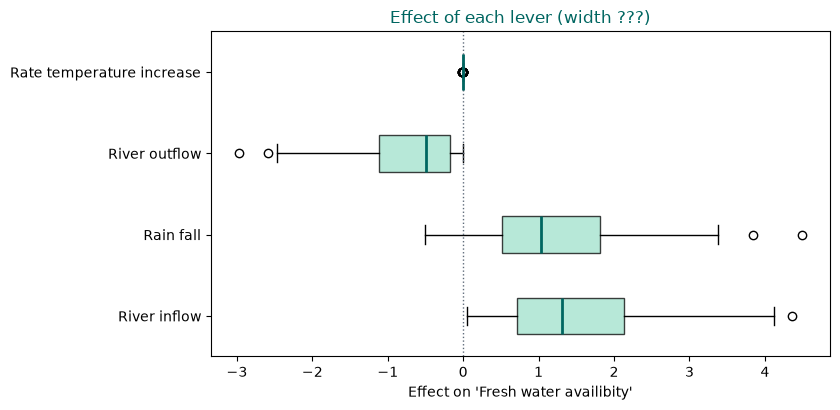

In [5]:
s.N, s.t_end, s.time_unit = 200, 25, "years"


def run(aux, stocks, seed):
    """Simulate at one pair of sampling bounds. Returns {lever: effects on the VOI}."""
    s.parameter_value_aux = aux
    s.parameter_value_stocks = stocks
    s.seed = seed
    sdm = SDM(s)
    sdm.run_simulations()
    return sdm.get_intervention_effects()[voi]


def rank(lev):
    """Collapse each lever's distribution to a median and a 5-95% interval."""
    return pd.DataFrame({k: {"median": np.median(v),
                             "lo": np.percentile(v, 5),
                             "hi": np.percentile(v, 95)} for k, v in lev.items()}).T


# TODO 1 - sampling bounds for the unknown link strengths (try 0.1)
base = run(aux=0.1, stocks=0.1, seed=7)

plot_spread(base, voi, "Effect of each lever (width ???)")

## 4. Which intervention variable matters most?

The D2D pay-off: leverage from a map alone. Look for one intervention variable clearly ahead, and note
whether the gap between variables is bigger than the spread within them.


,median,lo,hi
River inflow,1.307,0.193,3.430
Rain fall,1.028,0.092,2.911
Rate temperature increase,-0.001,-0.007,-0.000
River outflow,-0.487,-2.032,-0.019


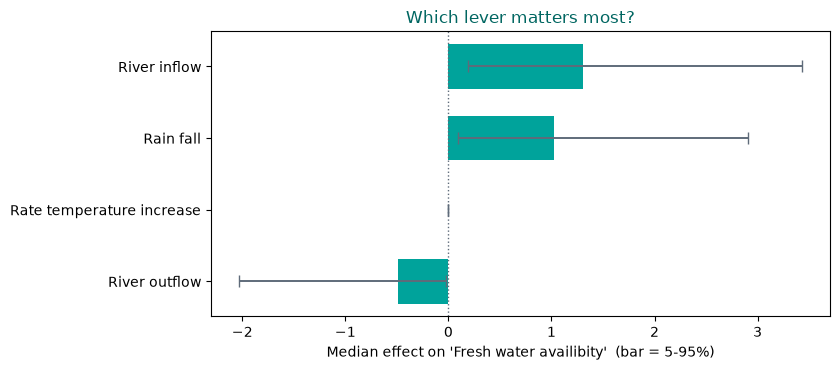

In [6]:
r = rank(base)
plot_ranking(r, voi)
r.sort_values("median", ascending=False).round(3)

## 5. Is the ranking robust?

A ranking from one set of assumptions can mislead. Widen the sampling and change the seed:
a robust conclusion survives, a fragile one flips. Expect the strongest lever to stay put
while close levers swap.

The robustness check repeats the analysis across several sampling bounds and random seeds.
Because the question here is only whether the importance ranking changes, the results are aggregated by variable across all runs.
Importance is based on the median effect, and is based on how large the median magnitude is.


In [10]:
# --- Ranking robustness across bounds and random seeds ------------------

bounds = [0.10, 0.15, 0.20]
seeds = range(1, 11)
s.N = 100

rows = []

for bound in bounds:
    for seed in seeds:
        effects = run(aux=bound, stocks=bound, seed=seed)
        medians = pd.Series({variable: np.median(values)
                             for variable, values in effects.items()})

        # Rank by median effect: 1 = highest median effect.
        ranks = medians.rank(ascending=False, method="min").astype(int)

        rows.extend(
            {"variable": variable, "rank": rank}
            for variable, rank in ranks.items()
        )

rank_runs = pd.DataFrame(rows)

# Percentage of runs in which each variable occupies each rank.
ranking_robustness = (
    rank_runs
    .groupby(["variable", "rank"])
    .size()
    .unstack(fill_value=0)
)

ranking_robustness = (
    ranking_robustness
    .div(ranking_robustness.sum(axis=1), axis=0)
    .mul(100)
    .rename(columns=lambda rank: f"rank_{int(rank)}_pct")
)

# Summary of how stable each variable's rank is.
ranking_robustness["most_common_rank"] = (
    rank_runs.groupby("variable")["rank"]
    .agg(lambda x: int(x.mode().iloc[0]))
)
ranking_robustness["consistency_pct"] = ranking_robustness.filter(like="rank_").max(axis=1)

ranking_robustness = ranking_robustness.sort_values("most_common_rank")
display(ranking_robustness.round(2))


Running Simulations:  48%|████▊     | 48/100 [00:01<00:01, 40.38it/s]

Running Simulations:  50%|█████     | 50/100 [00:01<00:01, 42.99it/s]

Running Simulations:  13%|█▎        | 13/100 [00:00<00:02, 37.85it/s]

Running Simulations:  37%|███▋      | 37/100 [00:00<00:01, 43.18it/s]

Running Simulations:  10%|█         | 10/100 [00:00<00:01, 45.10it/s]

...

Running Simulations:  57%|█████▋    | 57/100 [00:01<00:00, 45.81it/s]

Running Simulations:  73%|███████▎  | 73/100 [00:01<00:00, 46.87it/s]

Running Simulations:  93%|█████████▎| 93/100 [00:02<00:00, 45.53it/s]

Running Simulations: 100%|██████████| 100/100 [00:02<00:00, 44.78it/s]

rank,rank_1_pct,rank_2_pct,rank_3_pct,rank_4_pct,most_common_rank,consistency_pct
variable,,,,,,
River inflow,100.0,0.0,0.0,0.0,1,100.0
Rain fall,0.0,100.0,0.0,0.0,2,100.0
Rate temperature increase,0.0,0.0,100.0,0.0,3,100.0
River outflow,0.0,0.0,0.0,100.0,4,100.0
